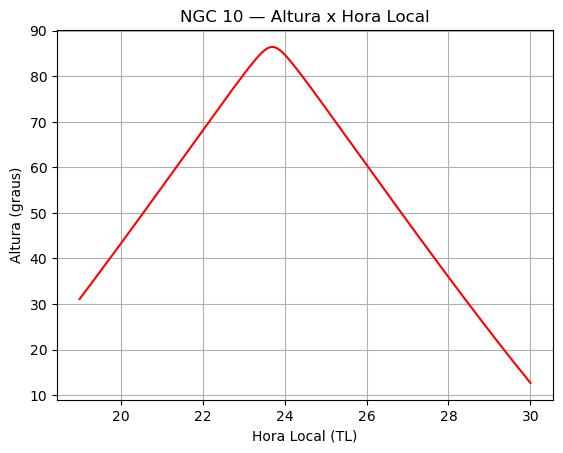

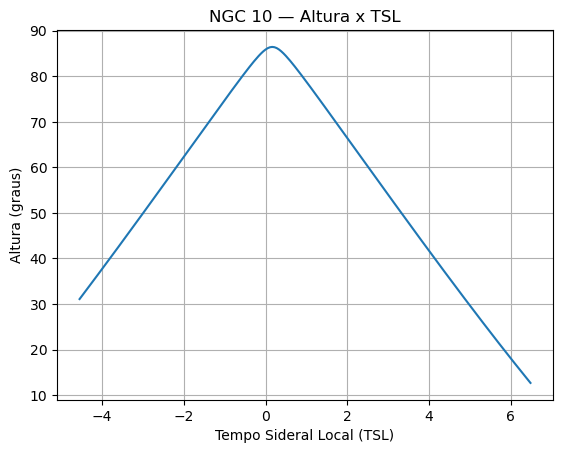

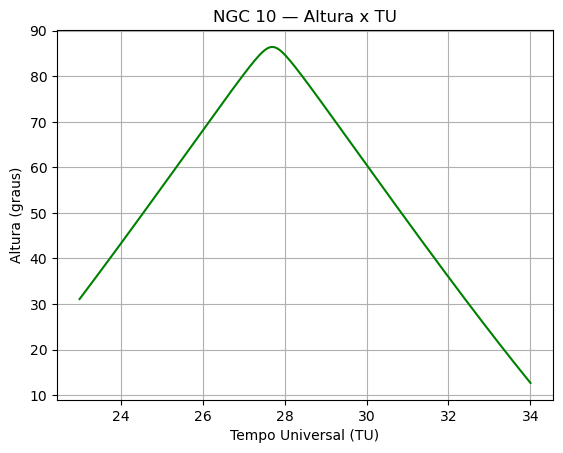

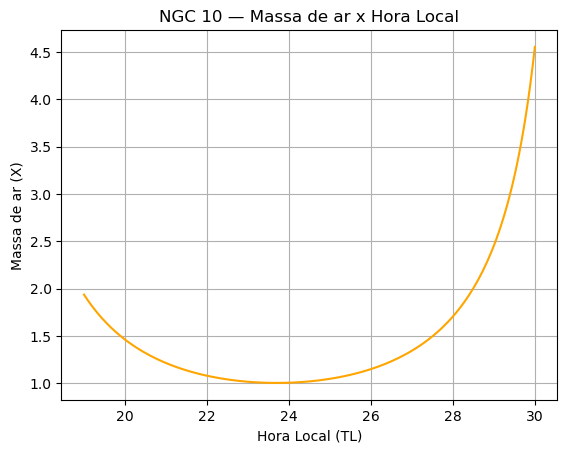

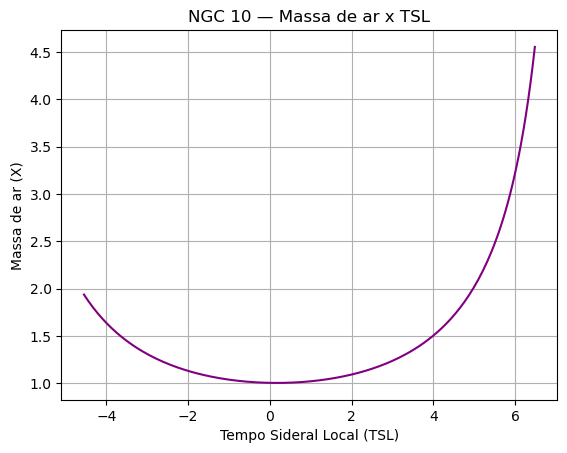

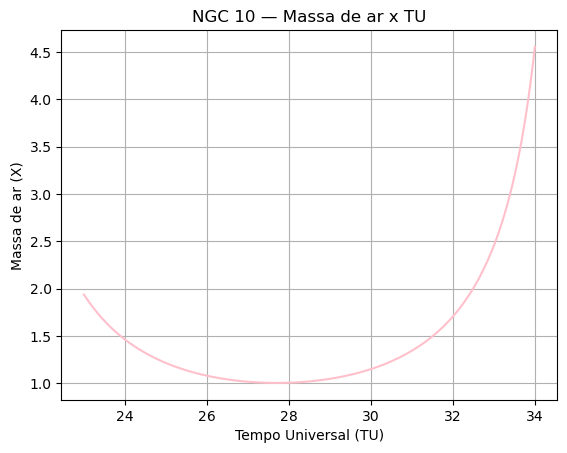

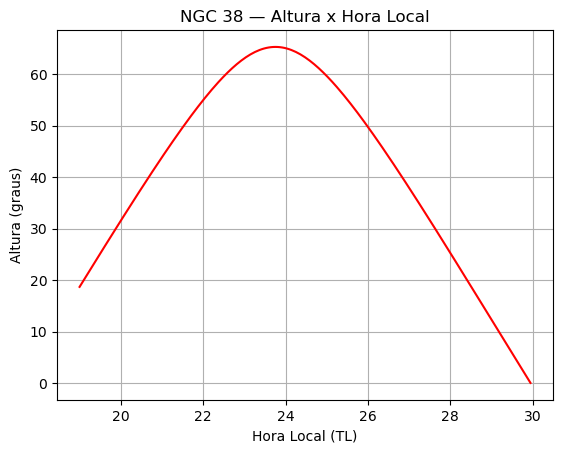

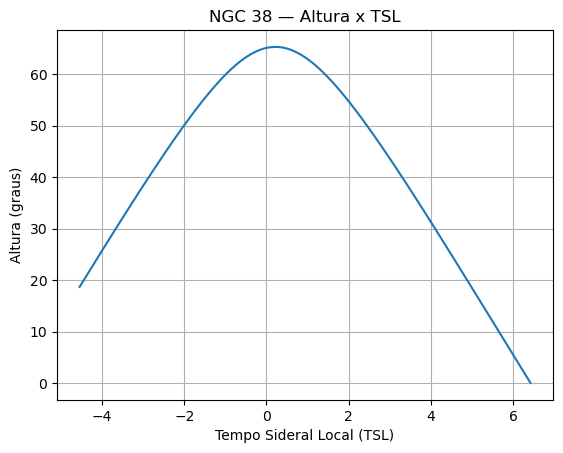

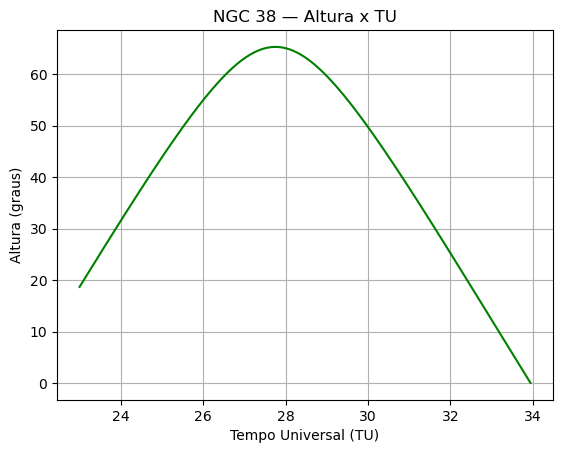

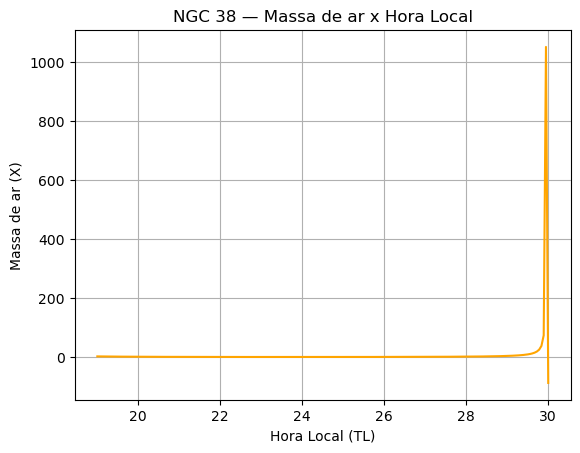

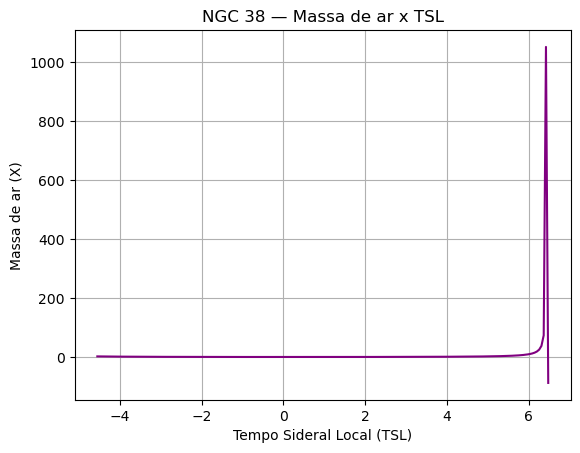

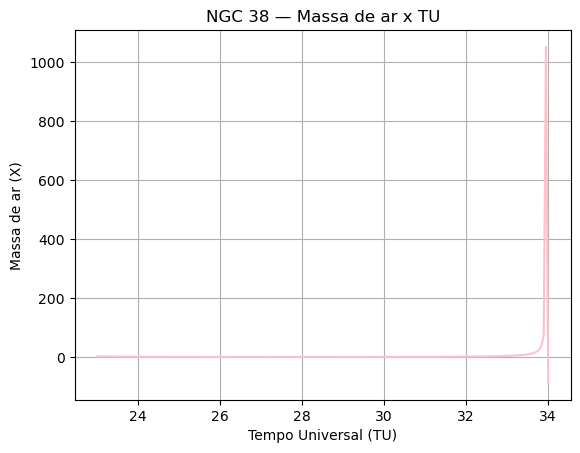

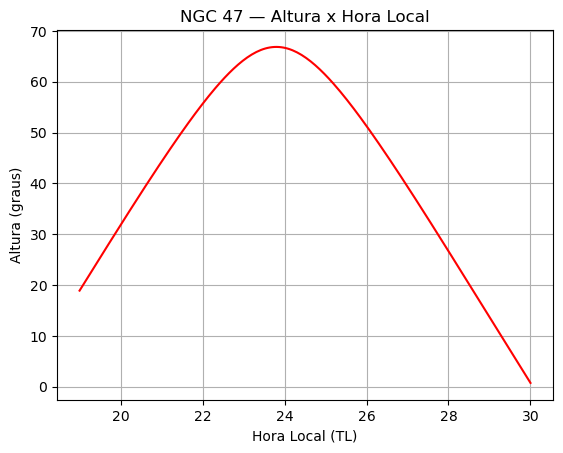

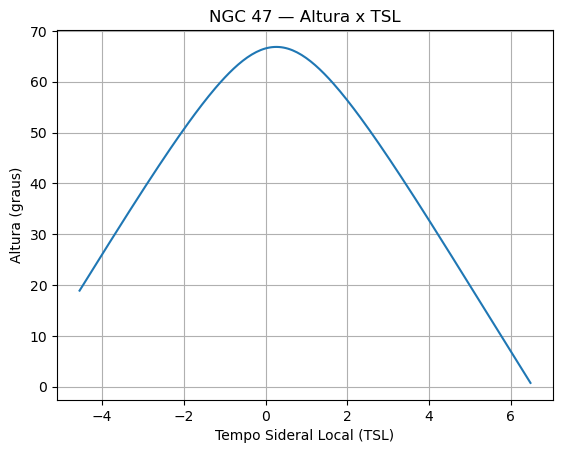

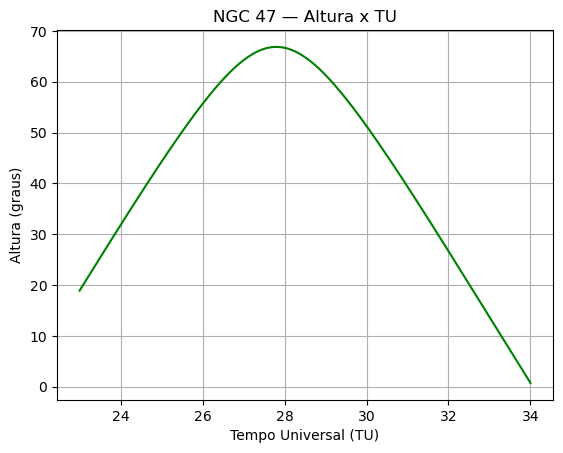

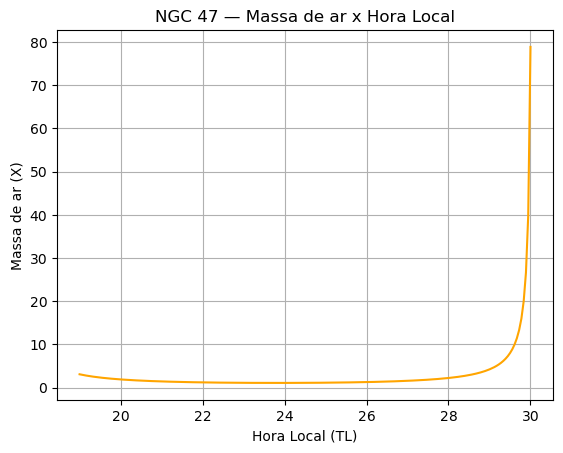

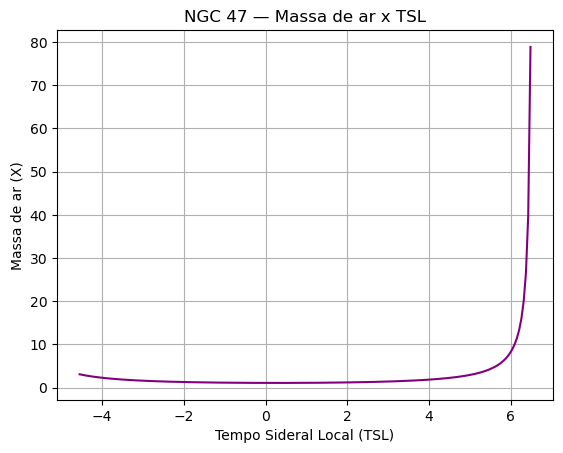

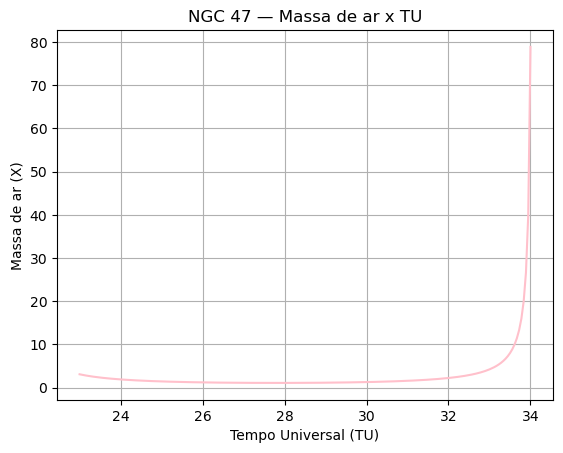

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# DADOS DOS OBJETOS SEPARADAMENTE
# ================================

objetos = {
    "NGC 10": {"RA": 0 + 9/60 + 56.4/3600, "dec": -33 - 42/60 - 34/3600},
    "NGC 38": {"RA": 0 + 13/60 + 8.1/3600, "dec": -5 - 26/60 - 4/3600},
    "NGC 47": {"RA": 0 + 15/60 + 52.0/3600, "dec": -7 - 1/60 - 5/3600}
}

# Conversão para radianos
for obj in objetos.values():
    obj["RA"] *= np.pi / 12
    obj["dec"] *= np.pi / 180

# ================================
# OBSERVATÓRIO (Cerro Tololo)
# ================================
lat = -30.165 * np.pi / 180  # latitude em rad

# ================================
# TEMPO
# ================================

# Hora local (19h → 6h)
TL = np.linspace(19, 30, 200)  # 30 = 6h do dia seguinte

# Converter para TU (CST = UT - 4)
TU = TL + 4

# TSL aproximado (linear)
TSL0 = 0.465  # ~00h27m
TSL = TSL0 + (TL - 24) * 1.0027379

# ================================
# FUNÇÕES
# ================================

def altura(dec, HA):
    return np.arcsin(
        np.sin(lat)*np.sin(dec) +
        np.cos(lat)*np.cos(dec)*np.cos(HA)
    )

def airmass(alt):
    z = np.pi/2 - alt
    return 1 / np.cos(z)

# ================================
# LOOP DOS OBJETOS
# ================================

for nome, obj in objetos.items():
    
    HA = (TSL * np.pi / 12) - obj["RA"]
    
    alt = altura(obj["dec"], HA)
    alt_deg = alt * 180 / np.pi
    
    X = airmass(alt)

    # remover valores abaixo do horizonte
    alt_deg[alt_deg < 0] = np.nan
    X[alt_deg < 0] = np.nan

    # ============================
    # GRÁFICOS
    # ============================

    # ALTURA
    plt.figure()
    plt.plot(TL, alt_deg, color='red')
    plt.xlabel("Hora Local (TL)")
    plt.ylabel("Altura (graus)")
    plt.title(f"{nome} — Altura x Hora Local")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(TSL, alt_deg)
    plt.xlabel("Tempo Sideral Local (TSL)")
    plt.ylabel("Altura (graus)")
    plt.title(f"{nome} — Altura x TSL")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(TU, alt_deg, color= 'green')
    plt.xlabel("Tempo Universal (TU)")
    plt.ylabel("Altura (graus)")
    plt.title(f"{nome} — Altura x TU")
    plt.grid()
    plt.show()

    # MASSA DE AR
    plt.figure()
    plt.plot(TL, X, color ='orange')
    plt.xlabel("Hora Local (TL)")
    plt.ylabel("Massa de ar (X)")
    plt.title(f"{nome} — Massa de ar x Hora Local")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(TSL, X, color='purple')
    plt.xlabel("Tempo Sideral Local (TSL)")
    plt.ylabel("Massa de ar (X)")
    plt.title(f"{nome} — Massa de ar x TSL")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(TU, X, color='pink')
    plt.xlabel("Tempo Universal (TU)")
    plt.ylabel("Massa de ar (X)")
    plt.title(f"{nome} — Massa de ar x TU")
    plt.grid()
    plt.show()

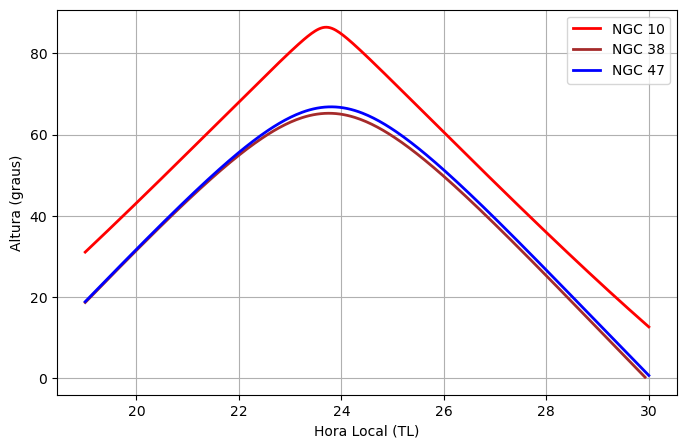

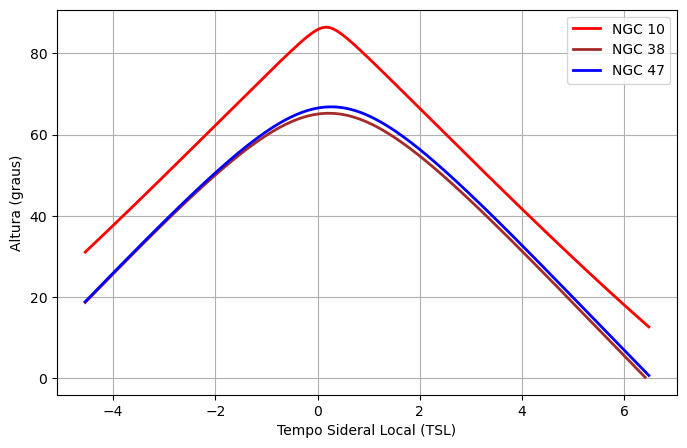

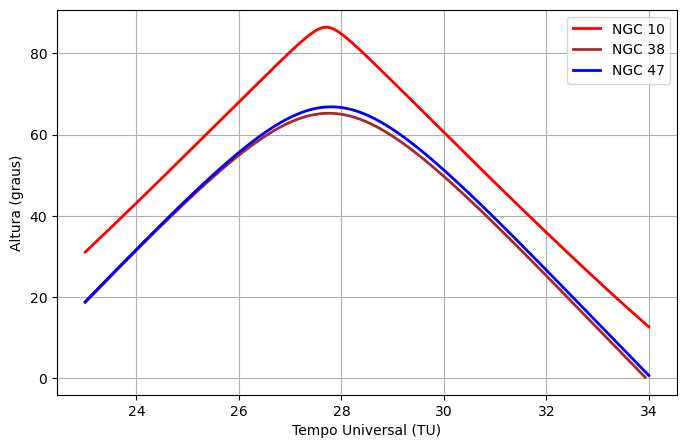

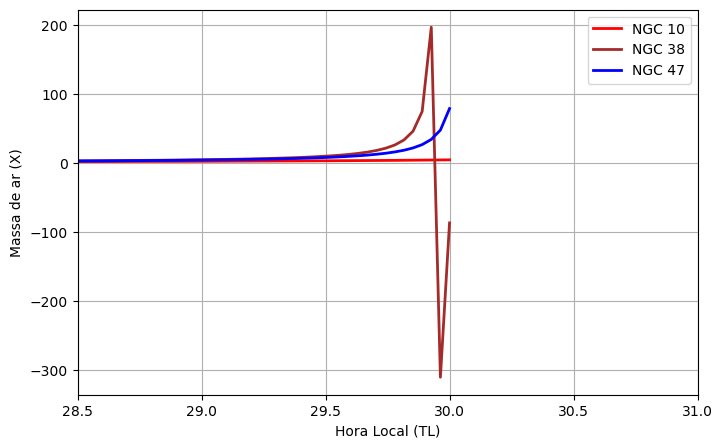

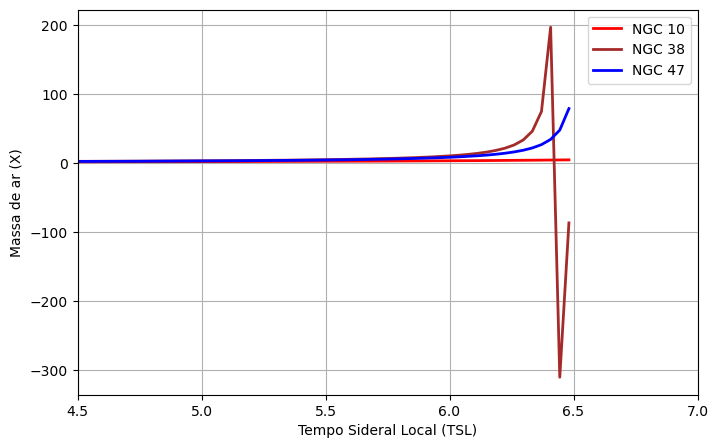

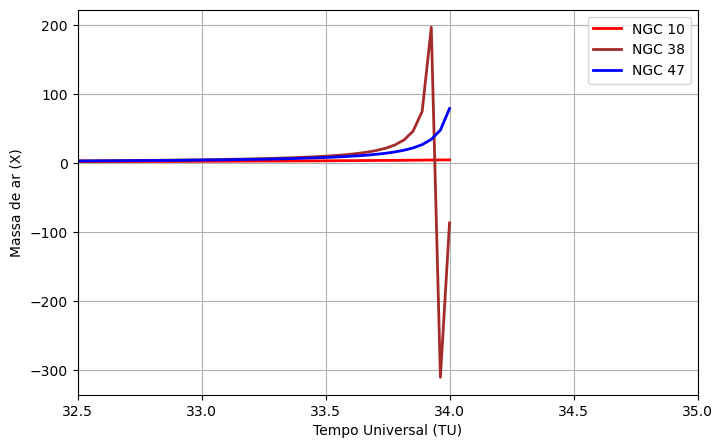

In [17]:


# ==========================================
# DADOS DOS OBJETOS
# ==========================================

objetos = {
    "NGC 10": {
        "RA": 0 + 9/60 + 56.4/3600,
        "dec": -33 - 42/60 - 34/3600,
        "cor": "red"
    },

    "NGC 38": {
        "RA": 0 + 13/60 + 8.1/3600,
        "dec": -5 - 26/60 - 4/3600,
        "cor": "brown"
    },

    "NGC 47": {
        "RA": 0 + 15/60 + 52.0/3600,
        "dec": -7 - 1/60 - 5/3600,
        "cor": "blue"
    }
}

# Conversão para radianos
for obj in objetos.values():
    obj["RA"] *= np.pi / 12
    obj["dec"] *= np.pi / 180

# ==========================================
# OBSERVATÓRIO
# ==========================================

lat = -30.165 * np.pi / 180

# ==========================================
# TEMPO
# ==========================================

TL = np.linspace(19, 30, 300)

TU = TL + 4

TSL0 = 0.465  # ~00h27m54s
TSL = TSL0 + (TL - 24) * 1.0027379

# ==========================================
# FUNÇÕES
# ==========================================

def altura(dec, HA):
    return np.arcsin(
        np.sin(lat)*np.sin(dec) +
        np.cos(lat)*np.cos(dec)*np.cos(HA)
    )

def airmass(alt):
    z = np.pi/2 - alt
    return 1 / np.cos(z)

# ==========================================
# RESULTADOS
# ==========================================

resultados = {}

for nome, obj in objetos.items():

    HA = (TSL * np.pi / 12) - obj["RA"]

    alt = altura(obj["dec"], HA)
    alt_deg = alt * 180 / np.pi

    X = airmass(alt)

    alt_deg[alt_deg < 0] = np.nan
    X[alt_deg < 0] = np.nan

    resultados[nome] = {
        "alt": alt_deg,
        "X": X
    }

# ==========================================
# 1) ALTURA × TL
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TL,
        resultados[nome]["alt"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Hora Local (TL)")
plt.ylabel("Altura (graus)")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 2) ALTURA × TSL
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TSL,
        resultados[nome]["alt"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Tempo Sideral Local (TSL)")
plt.ylabel("Altura (graus)")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 3) ALTURA × TU
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TU,
        resultados[nome]["alt"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Tempo Universal (TU)")
plt.ylabel("Altura (graus)")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 4) MASSA DE AR × TL
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TL,
        resultados[nome]["X"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Hora Local (TL)")
plt.ylabel("Massa de ar (X)")
plt.xlim(28.5, 31)
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 5) MASSA DE AR × TSL
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TSL,
        resultados[nome]["X"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Tempo Sideral Local (TSL)")
plt.ylabel("Massa de ar (X)")
plt.xlim(4.5, 7)
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 6) MASSA DE AR × TU
# ==========================================

plt.figure(figsize=(8,5))

for nome, obj in objetos.items():
    plt.plot(
        TU,
        resultados[nome]["X"],
        label=nome,
        color=obj["cor"],
        linewidth=2
    )

plt.xlabel("Tempo Universal (TU)")
plt.ylabel("Massa de ar (X)")
plt.xlim(32.5, 35)
plt.legend()
plt.grid()
plt.show()